# Imports/Setup:

In [1]:
# LLM Parsing:
import urllib3
import time
import statistics
import pandas as pd
from Ollama import OllamaChatSession

# Visualizations:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Settings:
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
sns.set_theme()

# Base Model Response Times:

In [ ]:
%%time
# Model list:
models = ['gpt-oss:20b', 'gpt-oss:120b', 'qwen3:4b', 'qwen3:8b', 'gemma3:12b', 'gemma3:27b']

# Number of runs per model
N = 100

# Simple test argument container to pass into initial_request:
class Args:
    def __init__(self):
        self.ingredients = 'chicken, rice, broccoli'
        self.allergens = None
        self.budget = None
        self.calories = None
test_args = Args()

# Storage for results:
results = []

# Loop over models:
for model in models:
    print(f'\nTesting {model}:')
    times = []

    for i in range(N):
        print(f'Run {i+1}/{N}...', end=' ')
        session = OllamaChatSession(
            model=model,
            url='http://ollama.loweffort.meme/api/chat',
            system_prompt='You are a recipe generator.',
            stream=True,
            verbose=False
        )

        start = time.time()
        try:
            _ = session.initial_request(test_args)
        except Exception as e:
            print(f'Error: {e}')
            times.append(float('nan'))
            continue

        elapsed = time.time() - start
        print(f'{elapsed:.2f} seconds')
        times.append(elapsed)

    # Compute statistics
    clean_times = [t for t in times if not pd.isna(t)]
    avg_time = statistics.mean(clean_times) if clean_times else float('nan')
    std_time = statistics.stdev(clean_times) if len(clean_times) > 1 else float('nan')

    row = {
        'model': model,
        'runs': len(clean_times),
        'avg_time_sec': avg_time,
        'std_dev_sec': std_time,
        'min_time_sec': min(clean_times) if clean_times else float('nan'),
        'max_time_sec': max(clean_times) if clean_times else float('nan'),
        'all_times': clean_times,
        }
    results.append(row)

# Convert to dataframe
results_df = pd.DataFrame(results)
results_df.to_csv('./basemodel_runtimes.csv', index=False)
results_df


Testing gpt-oss:20b:
Run 1/2... 15.34 seconds
Run 2/2... 8.50 seconds

Testing gpt-oss:120b:
Run 1/2... 144.75 seconds
Run 2/2... 135.03 seconds

Testing qwen3:4b:
Run 1/2... 21.53 seconds
Run 2/2... 7.69 seconds

Testing qwen3:8b:
Run 1/2... 11.51 seconds
Run 2/2... 9.39 seconds

Testing gemma3:12b:
Run 1/2... 17.27 seconds
Run 2/2... 13.73 seconds

Testing gemma3:27b:
Run 1/2... 29.80 seconds
Run 2/2... 25.29 seconds
CPU times: total: 1.17 s
Wall time: 7min 19s


,model,runs,avg_time_sec,std_dev_sec,min_time_sec,max_time_sec,all_times
0,gpt-oss:20b,2,11.922245,4.834102,8.504019,15.340471,"[15.340470790863037, 8.504018783569336]"
1,gpt-oss:120b,2,139.891864,6.873775,135.031372,144.752357,"[144.752357006073, 135.03137159347534]"
2,qwen3:4b,2,14.612665,9.789621,7.690357,21.534972,"[21.534972429275513, 7.690357446670532]"
3,qwen3:8b,2,10.451672,1.499542,9.391336,11.512008,"[11.512008428573608, 9.39133596420288]"
4,gemma3:12b,2,15.501252,2.505052,13.729913,17.272591,"[17.27259135246277, 13.729913473129272]"
5,gemma3:27b,2,27.545524,3.190426,25.289552,29.801497,"[29.801496505737305, 25.289552450180054]"


## Visualizations:

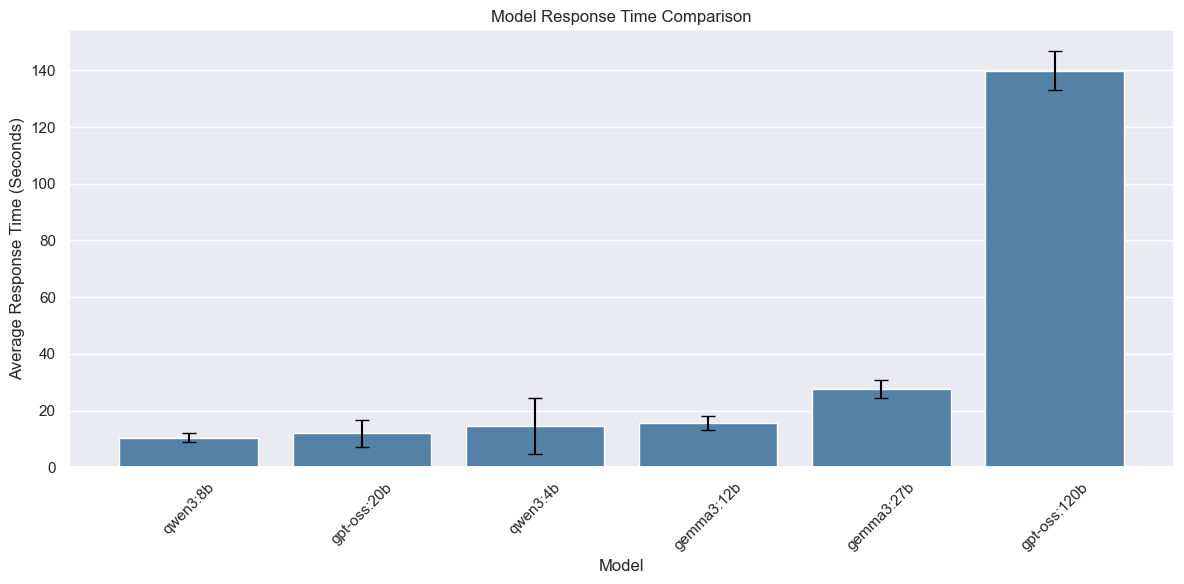

In [ ]:
# Create figure:
plot_df = results_df.sort_values('avg_time_sec')
plt.figure(figsize=(12, 6))

# Barplot:
ax = sns.barplot(
    data=plot_df,
    x='model',
    y='avg_time_sec',
    color='steelblue',
    )

# Error bars:
x_positions = np.arange(len(plot_df))
ax.errorbar(
    x=x_positions,
    y=plot_df['avg_time_sec'],
    yerr=plot_df['std_dev_sec'],
    fmt='none',
    ecolor='black',
    elinewidth=1.5,
    capsize=5,
    )

# Plot aesthetics:
plt.title(f'Model Response Time Comparison ({N} Runs)')
plt.xlabel('Model')
plt.ylabel('Average Response Time (Seconds)')
plt.xticks(x_positions, plot_df['model'], rotation=45)
plt.tight_layout()
plt.savefig('./BaseModel_Runtimes.jpg', dpi=600)
plt.show()